## **Importing necessary libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading Data**
**Load raw data csv file.**

In [2]:
df = pd.read_csv("./data/transformed/cleaned_bank_loan_data.csv")
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,0,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60,Source Verified,30000.0,0.0100,59.83,0.1527,2500.0,4,1009.0
1,1072053,CA,INDIVIDUAL,9,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36,Source Verified,48000.0,0.0535,109.43,0.1864,3000.0,4,3939.0
2,1069243,CA,INDIVIDUAL,4,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36,Not Verified,50000.0,0.2088,421.65,0.1596,12000.0,11,3522.0
3,1041756,TX,INDIVIDUAL,0,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60,Source Verified,42000.0,0.0540,97.06,0.1065,4500.0,9,4911.0
4,1068350,IL,INDIVIDUAL,10,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36,Verified,83000.0,0.0231,106.53,0.0603,3500.0,28,3835.0


## **Prepare data**

In [15]:
# Data validation X (features) và y (target)
X = df[['emp_length', 'term', 'annual_income', 'dti', 'int_rate', 'loan_amount', 'total_payment']]

def convert_loan_category(x):
    # Good Loan
    if x == 'Current' or x == 'Fully Paid':
        return 1
    # Bad Loan
    else:
        return 0

# Change data type from "Bad Loan" & "Good Loan" to 0 & 1
y = df['loan_status'].apply(convert_loan_category)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [17]:
x_test_data = pd.DataFrame(X_test)
x_test_data.to_csv("./application/x_test_data.csv", index=False)

## **1. Logistic Regression Model**

### Data Standardization

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Logistic Regression

In [5]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Model Evaluation

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.86      0.77      1067
           1       0.98      0.94      0.96      6649

    accuracy                           0.93      7716
   macro avg       0.84      0.90      0.86      7716
weighted avg       0.94      0.93      0.93      7716

Confusion Matrix:


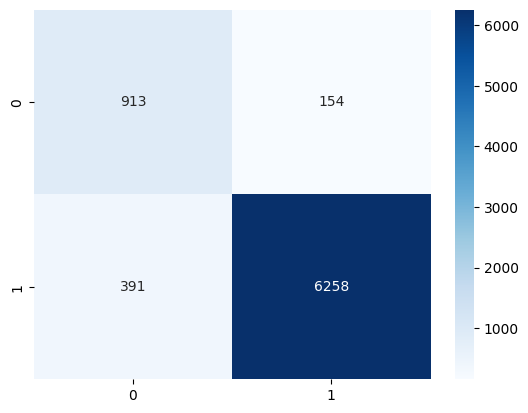

ROC AUC Score: 0.9477705422650249


In [6]:
y_pred = log_model.predict(X_test_scaled)
y_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

#### Explanation
- **Confusion Matrix**:
  - TP (True Positive) = 913 → Correct prediction Bad Loan.
  - TN (True Negative) = 6258 → Correct prediction Good Loan.
  - FP (False Positive) = 391 → Wrong prediction: predicted Bad but actually Good.
  - FN (False Negative) = 154 → Wrong prediction: predicted Good but actually Bad.

### Plot the ROC Curve

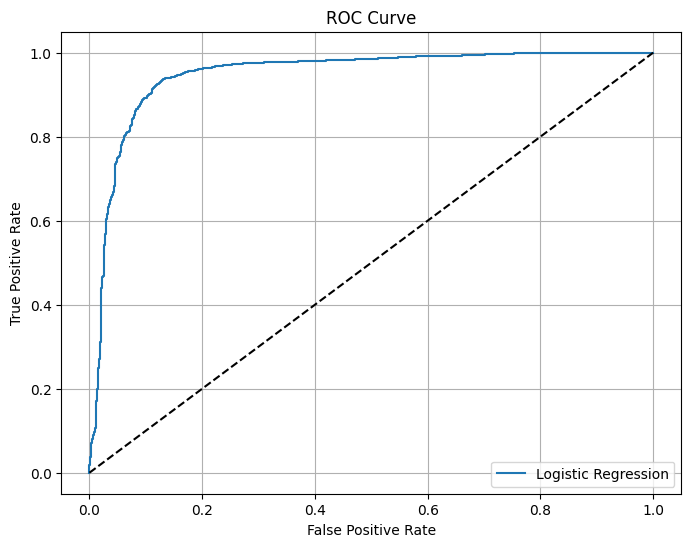

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

#### Explanation
- The ROC curve is very close to the upper left corner → this shows that the model has:
  - High TPR (True Positive Rate) → detects many "Bad Loans".
  - Low FPR (False Positive Rate) → less likely to mispredict "Good Loans" as "Bad Loans".

### Analyze model coefficients (understand the impact of each feature)

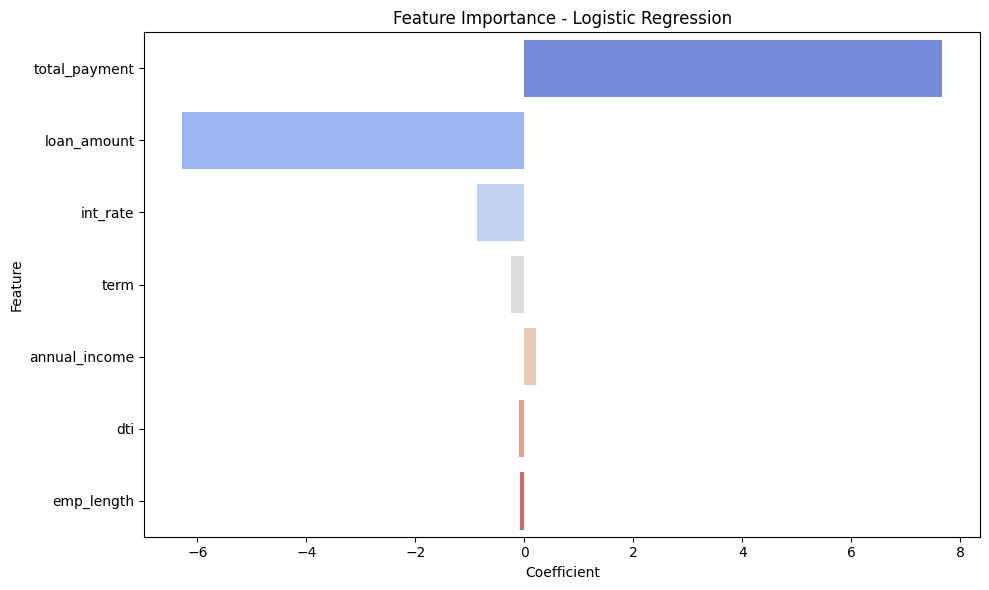

In [8]:
feature_weights = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_weights, palette='coolwarm')
plt.title('Feature Importance - Logistic Regression')
plt.tight_layout()
plt.show()

#### Explanation
- **Total_payment** has the **strongest** negative effect, indicating that: if the customer has **paid a lot of money**, **the risk is very low**.
- **Loan_amount** has a very strong and positive effect → **borrowing a lot**, high pressure to pay → **easy to default**.
- **Int_rate & DTI** also increase risk as expected.
- **Annual_income reduces risk** → reflects better debt repayment ability.

### **Save and deploy the model**

In [61]:
import pickle

# Lưu model và scaler
with open('./model/logistic_model.pkl', 'wb') as f:
    pickle.dump(log_model, f)

with open('./model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

### **Predictions on new data**

In [38]:
import pickle

# Load model và scaler
with open('./model/logistic_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('./model/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

In [41]:
# Tạo input đúng format
sample = pd.DataFrame({
    'emp_length': [1],
    'term': [36],
    'annual_income': [90000.0],
    'dti': [0.04],
    'int_rate': [0.06],
    'loan_amount': [20000.0],
    'total_payment': [10000.0]
})

# Scale và dự đoán
sample_scaled = scaler.transform(sample)
proba = model.predict_proba(sample_scaled)[0][0]
print(f'Xác suất Bad Loan: {proba:.2%}')

Xác suất Bad Loan: 99.81%


## **2. Decision Tree Model**

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

#Train Model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:,1]

# Evaluation
y_pred_dt = dt_model.predict(X_test)
print(classification_report(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      1067
           1       0.95      0.99      0.97      6649

    accuracy                           0.94      7716
   macro avg       0.92      0.83      0.87      7716
weighted avg       0.94      0.94      0.94      7716

ROC AUC: 0.8917774558061524


In [42]:
# Tạo input đúng format
sample = pd.DataFrame({
    'emp_length': [1],
    'term': [36],
    'annual_income': [90000.0],
    'dti': [0.04],
    'int_rate': [0.06],
    'loan_amount': [20000.0],
    'total_payment': [10000.0]
})

# Scale và dự đoán
proba = dt_model.predict_proba(sample)[0][0]
print(f'Xác suất Bad Loan: {proba:.2%}')

Xác suất Bad Loan: 56.57%


## **3. Random Forest Model**

              precision    recall  f1-score   support

           0       0.95      0.73      0.82      1067
           1       0.96      0.99      0.98      6649

    accuracy                           0.96      7716
   macro avg       0.95      0.86      0.90      7716
weighted avg       0.96      0.96      0.95      7716

ROC AUC Score: 0.9638244957384491
Confusion Matrix:



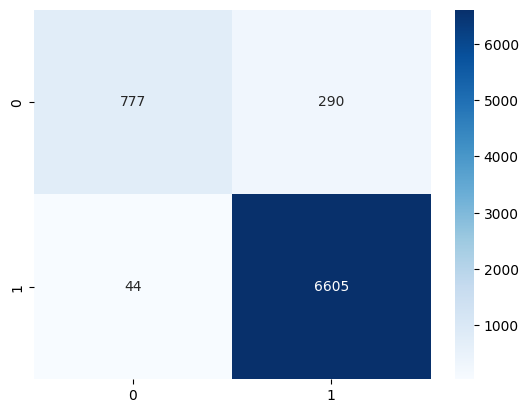

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Khởi tạo và huấn luyện mô hình
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Đánh giá mô hình
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

In [53]:
# Tạo input đúng format
sample = pd.DataFrame({
    'emp_length': [1],
    'term': [36],
    'annual_income': [90000.0],
    'dti': [0.04],
    'int_rate': [0.06],
    'loan_amount': [20000.0],
    'total_payment': [10000.0]
})

# Scale và dự đoán
proba = rf_model.predict_proba(sample)[0][0]
print(f'Xác suất Bad Loan: {proba:.2%}')

Xác suất Bad Loan: 8.00%


## **4. XGBoost (Extreme Gradient Boosting) Model**

### Train model

c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


              precision    recall  f1-score   support

           0       0.94      0.77      0.85      1067
           1       0.96      0.99      0.98      6649

    accuracy                           0.96      7716
   macro avg       0.95      0.88      0.91      7716
weighted avg       0.96      0.96      0.96      7716

ROC AUC Score: 0.9709994371682898
Confusion Matrix:



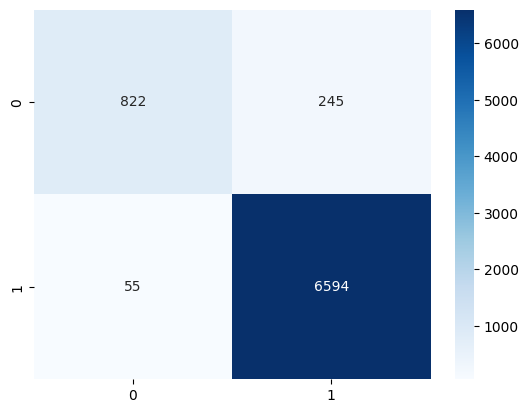

In [54]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Khởi tạo và huấn luyện mô hình
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Dự đoán
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Đánh giá mô hình
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

### Storage model

In [60]:
import pickle

# Store model và scaler
with open('./model/xgbboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

In [ ]:
# Load model và scaler
with open('./model/xgbboost_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)
    
# Tạo input đúng format
sample = pd.DataFrame({
    'emp_length': [0],
    'term': [36],
    'annual_income': [20000.0],
    'dti': [0.12],
    'int_rate': [0.1],
    'loan_amount': [20000.0],
    'total_payment': [5000.0]
})

# Scale và dự đoán
proba = xgb_model.predict_proba(sample)[0][0]
print(f'Xác suất Bad Loan: {proba:.2%}')

Xác suất Bad Loan: 94.48%


### Use SHAP to explain the model

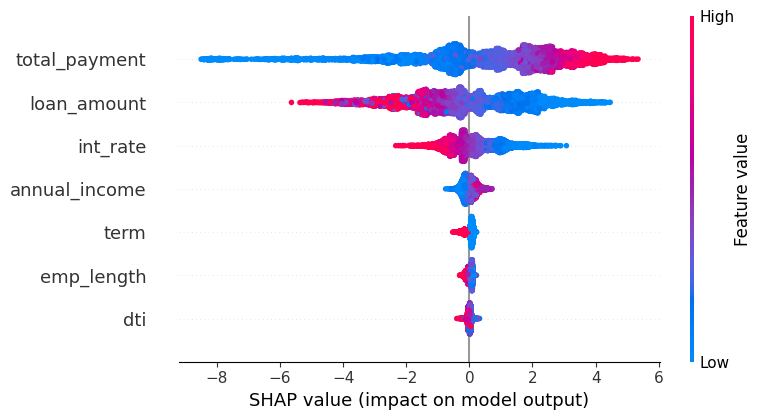

In [61]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

### Explanation
- Top 3 factors that have the **greatest impact** on prediction: **total_payment, loan_amount, int_rate**.
  - **total_payment**:
    - When total_payment is high (red) → SHAP value is negative → reduces the possibility of Bad Loan → that is: the person who pays more is usually a Good Loan.
    - When total_payment is low (green) → SHAP value is positive → increases the risk of Bad Loan.
    - **Very reasonable**: the borrower who pays less is usually a risky signal.
  -  **loan_amount**:
     -  When the loan amount is high (red) → SHAP value is positive → increases the possibility of Bad Loan.
     -  When low (green) → is likely to be Good Loan.
     -  **Meaning**: borrowing more money means higher risk.
  -  **int_rate**:
     -  High interest rate (red) → Positive SHAP value → increases the risk of Bad Loan.
     -  Low interest rate → Negative SHAP value → likely to be Good Loan.
     -  **Reasonable**: high interest rate is often applied to risky customers → likely to default.
- Features such as **annual_income, term, emp_length, dti** have **less impact**.
-> The model is learning the true nature of the relationship between financial information and credit risk.